# stagev3 selected stability result check


## Section 0. File audit and run status


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path("..")
FINAL = ROOT / "output" / "final_report"
THRESHOLD = 0.75
RUN_COMMAND = "python run_stagev3.py --mode selected_after_seed2026 --seeds 0-29 --cv-mode exact --min-external-accuracy 0.75 --n-jobs 8 --resume"

def read_csv_safe(path):
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        print(f"WARNING: cannot read {path}: {exc}")
        return pd.DataFrame()

def read_json_safe(path):
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        print(f"WARNING: cannot read {path}: {exc}")
        return {}

def available(frame, columns):
    return [column for column in columns if column in frame.columns]

paths = {
    "seed2026_main": FINAL / "seed2026_main_results.csv",
    "selected_models": FINAL / "selected_model_specs_external075.csv",
    "selected_models_md": FINAL / "selected_model_specs_external075.md",
    "selected_results": FINAL / "selected_seed_stability_results_external075.csv",
    "selected_summary": FINAL / "selected_seed_stability_summary_external075.csv",
    "selected_summary_md": FINAL / "selected_seed_stability_summary_external075.md",
    "selected_manifest": FINAL / "selected_run_manifest_external075.json",
    "predictions": FINAL / "seed2026_external_predictions_all_models.csv",
    "run_progress": FINAL / "run_progress.json",
    "validation_report": FINAL / "validation_report.md",
}

main = read_csv_safe(paths["seed2026_main"])
selected = read_csv_safe(paths["selected_models"])
results = read_csv_safe(paths["selected_results"])
summary = read_csv_safe(paths["selected_summary"])
predictions = read_csv_safe(paths["predictions"])
manifest = read_json_safe(paths["selected_manifest"])
run_progress = read_json_safe(paths["run_progress"])

audit_rows = []
for name, file_path in paths.items():
    row = {"name": name, "path": str(file_path), "exists": file_path.exists()}
    if file_path.suffix.lower() == ".csv":
        frame = {"seed2026_main": main, "selected_models": selected, "selected_results": results,
                  "selected_summary": summary, "predictions": predictions}.get(name, pd.DataFrame())
        row["rows"] = len(frame) if file_path.exists() else np.nan
    audit_rows.append(row)
display(pd.DataFrame(audit_rows))

old_079 = sorted(FINAL.glob("*external079*"))
if old_079:
    print("NOTE: old external079 files detected; they are not used by this notebook:")
    for old_path in old_079:
        print(" -", old_path.name)

selected_count = int(manifest.get("selected_model_count", len(selected)))
n_seeds = int(manifest.get("n_seeds", results["seed"].nunique() if "seed" in results else 0))
expected_rows = selected_count * n_seeds
stable_candidate_count = int(
    (pd.to_numeric(summary["external_accuracy_mean"], errors="coerce") >= THRESHOLD).sum()
) if "external_accuracy_mean" in summary else 0
status = pd.DataFrame([{
    "selected_model_count": selected_count,
    "stable_candidate_count": stable_candidate_count,
    "n_seeds": n_seeds,
    "actual_selected_stability_rows": len(results),
    "expected_selected_stability_rows": expected_rows,
    "row_count_matches": len(results) == expected_rows if expected_rows else False,
    "completed_seed_count": manifest.get("completed_seed_count"),
    "missing_seed_ids": manifest.get("missing_seed_ids"),
    "n_jobs": manifest.get("n_jobs"),
}])
display(status)
if summary.empty or results.empty:
    display(Markdown("**WARNING:** selected stability outputs are missing or empty. Run:"))
    print(RUN_COMMAND)


,name,path,exists,rows
0,seed2026_main,..\output\final_report\seed2026_main_results.csv,True,204.0
1,selected_models,..\output\final_report\selected_model_specs_ex...,True,35.0
2,selected_models_md,..\output\final_report\selected_model_specs_ex...,True,NaN
3,selected_results,..\output\final_report\selected_seed_stability...,True,105.0
4,selected_summary,..\output\final_report\selected_seed_stability...,True,35.0
5,selected_summary_md,..\output\final_report\selected_seed_stability...,True,NaN
6,selected_manifest,..\output\final_report\selected_run_manifest_e...,True,NaN
7,predictions,..\output\final_report\seed2026_external_predi...,True,14484.0
8,run_progress,..\output\final_report\run_progress.json,True,NaN
9,validation_report,..\output\final_report\validation_report.md,True,NaN


NOTE: old external079 files detected; they are not used by this notebook:
 - selected_stability_checkpoints_external079


,selected_model_count,stable_candidate_count,n_seeds,actual_selected_stability_rows,expected_selected_stability_rows,row_count_matches,completed_seed_count,missing_seed_ids,n_jobs
0,35,0,30,105,1050,False,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",12


## Section 1. Seed2026 all-model ranking


,early_variant,model_spec_id,feature_block,classifier_name,model_family,external_accuracy,external_precision,external_recall,external_f1,external_auc,n_features
29,earlyv0,early_middle__svc__poly3,early_middle,svc__poly3,svc,0.845070,0.785714,0.942857,0.857143,0.855556,1086
163,earlyv1,all__svc__poly3,all,svc__poly3,svc,0.830986,0.767442,0.942857,0.846154,0.851587,1100
61,earlyv0,all__svc__poly3,all,svc__poly3,svc,0.830986,0.767442,0.942857,0.846154,0.850000,1099
131,earlyv1,early_middle__svc__poly3,early_middle,svc__poly3,svc,0.830986,0.780488,0.914286,0.842105,0.856349,1087
37,earlyv0,early_middle_scale__svc__poly3,early_middle_scale,svc__poly3,svc,0.802817,0.744186,0.914286,0.820513,0.853968,1148
139,earlyv1,early_middle_scale__svc__poly3,early_middle_scale,svc__poly3,svc,0.802817,0.744186,0.914286,0.820513,0.853175,1150
13,earlyv0,middle_only__svc__poly3,middle_only,svc__poly3,svc,0.802817,0.756098,0.885714,0.815789,0.846825,1025
115,earlyv1,middle_only__svc__poly3,middle_only,svc__poly3,svc,0.802817,0.756098,0.885714,0.815789,0.846825,1025
45,earlyv0,middle_late__svc__poly3,middle_late,svc__poly3,svc,0.788732,0.738095,0.885714,0.805195,0.838889,1038
147,earlyv1,middle_late__svc__poly3,middle_late,svc__poly3,svc,0.788732,0.738095,0.885714,0.805195,0.838889,1038


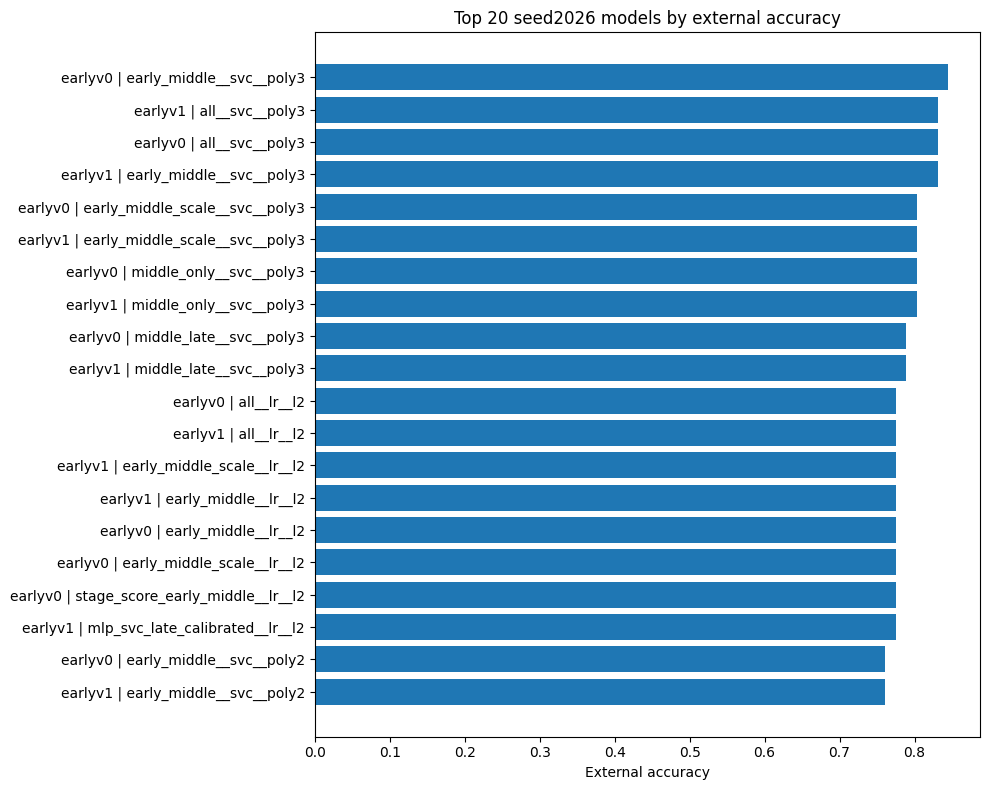

In [2]:
if main.empty:
    print("WARNING: seed2026_main_results.csv is unavailable.")
else:
    main_view = main.copy()
    if "classifier_name" not in main_view:
        main_view["classifier_name"] = main_view.get("model_name", main_view.get("model_variant", ""))
    if "model_family" not in main_view:
        main_view["model_family"] = main_view.get("model_variant", main_view["classifier_name"]).astype(str).str.split("__").str[0]
    sort_cols = available(main_view, ["external_accuracy", "external_f1", "external_auc"])
    ranked_main = main_view.sort_values(sort_cols, ascending=False) if sort_cols else main_view
    main_columns = available(ranked_main, [
        "early_variant", "model_spec_id", "feature_block", "classifier_name",
        "model_family", "external_accuracy", "external_precision",
        "external_recall", "external_f1", "external_auc", "n_features",
    ])
    display(ranked_main[main_columns].head(20))
    if {"external_accuracy", "model_spec_id"} <= set(ranked_main.columns):
        plot_data = ranked_main.head(20).copy().iloc[::-1]
        labels = plot_data.get("early_variant", "").astype(str) + " | " + plot_data["model_spec_id"].astype(str)
        plt.figure(figsize=(10, 8))
        plt.barh(labels, plot_data["external_accuracy"])
        plt.xlabel("External accuracy")
        plt.title("Top 20 seed2026 models by external accuracy")
        plt.tight_layout()
        plt.show()


## Section 2. Selected model audit


In [3]:
if selected.empty:
    print("WARNING: selected_model_specs_external075.csv is unavailable.")
else:
    threshold_values = selected["selection_threshold"].dropna().unique().tolist() if "selection_threshold" in selected else []
    print("selection_threshold:", threshold_values)
    print("selected_model_count:", len(selected))
    print("selected proportion:", len(selected) / len(main) if len(main) else np.nan)
    for column in ["early_variant", "feature_block", "classifier_name"]:
        if column in selected:
            display(selected[column].value_counts(dropna=False).rename("count").to_frame())
    if "external_accuracy" in selected:
        invalid_selected = selected[pd.to_numeric(selected["external_accuracy"], errors="coerce") < THRESHOLD]
        if invalid_selected.empty:
            print("PASS: all selected models satisfy external_accuracy >= 0.75")
        else:
            print("WARNING: selected models below threshold:")
            display(invalid_selected)


selection_threshold: [0.75]
selected_model_count: 35
selected proportion: 0.1715686274509804


,count
early_variant,
earlyv0,18
earlyv1,17


,count
feature_block,
early_middle,13
all,6
early_middle_scale,6
middle_late,4
middle_only,2
all_plus_interactions,2
middle_late_scale,2


,count
classifier_name,
svc__poly3,10
svc__poly2,8
lr__l2,6
svc__rbf,4
lr__elasticnet,2
svc__sigmoid,2
stage_score_early_middle__lr__l2,1
mlp_svc_late_calibrated__lr__l2,1
early_middle__mlp__small,1


PASS: all selected models satisfy external_accuracy >= 0.75


## Section 3. Selected stability summary ranking


In [4]:
if summary.empty:
    print("WARNING: selected_seed_stability_summary_external075.csv is unavailable.")
    ranked_summary = pd.DataFrame()
    filtered_summary = pd.DataFrame()
else:
    filtered_summary = summary[
        pd.to_numeric(summary["external_accuracy_mean"], errors="coerce") >= THRESHOLD
    ].copy() if "external_accuracy_mean" in summary else pd.DataFrame()
    ranking = available(filtered_summary, [
        "external_accuracy_mean", "external_f1_mean", "external_auc_mean",
    ])
    ranked_summary = filtered_summary.sort_values(ranking, ascending=False) if ranking else filtered_summary.copy()
    print("selected_model_count:", len(selected))
    print("stable_candidate_count:", len(filtered_summary))
    if filtered_summary.empty:
        print("WARNING: no models satisfy multi-seed external_accuracy_mean >= 0.75.")
    summary_columns = available(ranked_summary, [
        "early_variant", "model_spec_id", "feature_block", "classifier_name",
        "model_family", "n_seeds", "seed2026_external_accuracy",
        "external_accuracy_mean", "external_accuracy_std",
        "external_accuracy_min", "external_accuracy_max",
        "external_precision_mean", "external_recall_mean",
        "external_f1_mean", "external_auc_mean",
    ])
    display(ranked_summary[summary_columns].head(30))


selected_model_count: 35
stable_candidate_count: 0


,early_variant,model_spec_id,feature_block,classifier_name,model_family,n_seeds,seed2026_external_accuracy,external_accuracy_mean,external_accuracy_std,external_accuracy_min,external_accuracy_max,external_precision_mean,external_recall_mean,external_f1_mean,external_auc_mean


## Section 4. External accuracy mean plot


In [5]:
mean_required = {"external_accuracy_mean"}
if filtered_summary.empty:
    print("WARNING: no models satisfy external_accuracy_mean >= 0.75; no mean plot is shown.")
elif not mean_required <= set(filtered_summary.columns):
    print("WARNING: external_accuracy_mean is unavailable.")
else:
    mean_ranking = available(filtered_summary, [
        "external_accuracy_mean", "external_f1_mean", "external_auc_mean",
    ])
    mean_plot = filtered_summary.sort_values(mean_ranking, ascending=False).dropna(
        subset=list(mean_required)
    ).head(30).copy().iloc[::-1]
    if mean_plot.empty:
        print("WARNING: no complete mean accuracy rows are available.")
    else:
        labels = (
            mean_plot.get("early_variant", "").astype(str) + " | " +
            mean_plot.get("feature_block", "").astype(str) + " | " +
            mean_plot.get("classifier_name", mean_plot.get("model_spec_id", "")).astype(str)
        )
        plt.figure(figsize=(11, 10))
        plt.barh(labels, mean_plot["external_accuracy_mean"])
        plt.axvline(THRESHOLD, linestyle="--")
        plt.xlabel("Mean external accuracy")
        plt.title("Selected models mean external accuracy")
        plt.tight_layout()
        plt.show()


## Section 5. Seed2026 accuracy vs multi-seed stability mean


,early_variant,model_spec_id,seed2026_external_accuracy,external_accuracy_mean,stability_gap
8,earlyv0,early_middle__svc__poly3,0.845070,0.676056,-0.169014
20,earlyv1,early_middle__svc__poly3,0.830986,0.661972,-0.169014
18,earlyv0,all__svc__poly3,0.830986,0.661972,-0.169014
19,earlyv1,all__svc__poly3,0.830986,0.661972,-0.169014
21,earlyv1,early_middle_scale__svc__poly3,0.802817,0.661972,-0.140845
9,earlyv0,early_middle_scale__svc__poly3,0.802817,0.676056,-0.126761
23,earlyv0,stage_score_early_middle__lr__l2,0.774648,0.661972,-0.112676
22,earlyv0,all__lr__l2,0.774648,0.661972,-0.112676
24,earlyv1,all__lr__l2,0.774648,0.661972,-0.112676
25,earlyv1,early_middle__lr__l2,0.774648,0.661972,-0.112676


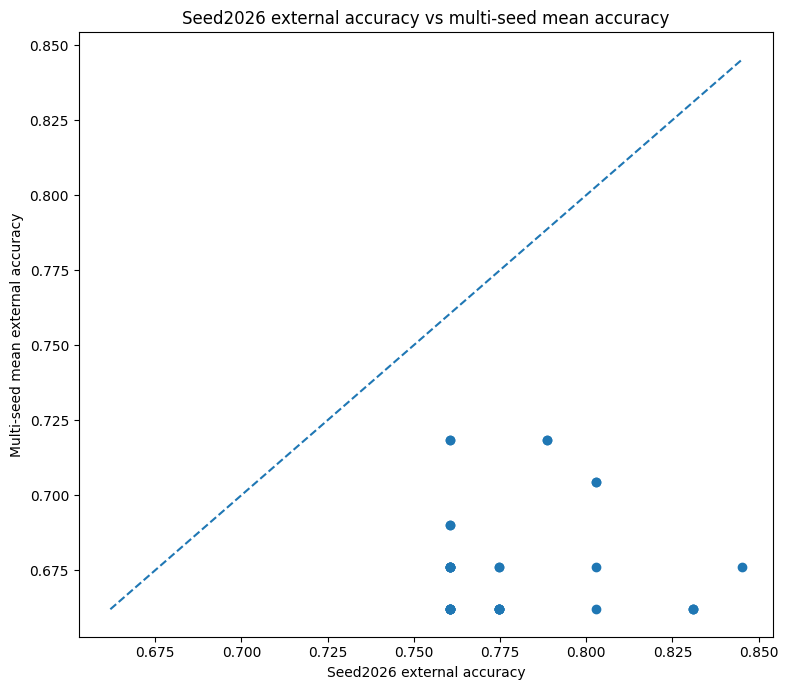

In [6]:
gap_required = {"seed2026_external_accuracy", "external_accuracy_mean"}
if summary.empty or not gap_required <= set(summary.columns):
    print("WARNING: seed2026/stability comparison columns are unavailable.")
else:
    gap_table = summary.copy()
    gap_table["stability_gap"] = gap_table["external_accuracy_mean"] - gap_table["seed2026_external_accuracy"]
    gap_columns = available(gap_table, [
        "early_variant", "model_spec_id", "seed2026_external_accuracy",
        "external_accuracy_mean", "stability_gap",
    ])
    display(gap_table.sort_values("stability_gap")[gap_columns])
    plot_gap = gap_table.dropna(subset=list(gap_required))
    if not plot_gap.empty:
        low = min(plot_gap["seed2026_external_accuracy"].min(), plot_gap["external_accuracy_mean"].min())
        high = max(plot_gap["seed2026_external_accuracy"].max(), plot_gap["external_accuracy_mean"].max())
        plt.figure(figsize=(8, 7))
        plt.scatter(plot_gap["seed2026_external_accuracy"], plot_gap["external_accuracy_mean"])
        plt.plot([low, high], [low, high], linestyle="--")
        plt.xlabel("Seed2026 external accuracy")
        plt.ylabel("Multi-seed mean external accuracy")
        plt.title("Seed2026 external accuracy vs multi-seed mean accuracy")
        plt.tight_layout()
        plt.show()


## Section 6. Across-seed distribution


In [7]:
if results.empty or "seed" not in results or "external_accuracy" not in results:
    print("WARNING: selected per-seed results are unavailable.")
else:
    seed_distribution = results.groupby("seed")["external_accuracy"].agg(
        mean_external_accuracy="mean",
        max_external_accuracy="max",
        min_external_accuracy="min",
        selected_model_runs="size",
    ).reset_index()
    display(seed_distribution)
    if not ranked_summary.empty and "model_spec_id" in ranked_summary:
        top_keys = ranked_summary.head(10)[available(ranked_summary, ["early_variant", "model_spec_id"])]
        top_results = results.merge(top_keys, on=available(top_keys, ["early_variant", "model_spec_id"]), how="inner")
        groups, labels = [], []
        for key, group in top_results.groupby(available(top_results, ["early_variant", "model_spec_id"]), sort=False):
            groups.append(group["external_accuracy"].dropna().to_numpy())
            labels.append(" | ".join(map(str, key if isinstance(key, tuple) else (key,))))
        if groups:
            plt.figure(figsize=(11, 7))
            plt.boxplot(groups, labels=labels, vert=False)
            plt.xlabel("External accuracy across seeds")
            plt.title("Top 10 selected models across-seed accuracy")
            plt.tight_layout()
            plt.show()


,seed,mean_external_accuracy,max_external_accuracy,min_external_accuracy,selected_model_runs
0,0,0.676459,0.71831,0.661972,35
1,1,0.676459,0.71831,0.661972,35
2,2,0.676459,0.71831,0.661972,35


## Section 7. Stability labels


In [8]:
if summary.empty or "external_accuracy_mean" not in summary.columns:
    print("WARNING: stability mean is unavailable.")
    robust_summary = pd.DataFrame()
else:
    robust_summary = summary.copy()
    robust_summary["stability_label"] = np.where(
        pd.to_numeric(robust_summary["external_accuracy_mean"], errors="coerce") >= THRESHOLD,
        "stable_candidate",
        "below_threshold",
    )
    display(robust_summary["stability_label"].value_counts().rename("count").to_frame())
    stable_robustness = robust_summary[
        pd.to_numeric(robust_summary["external_accuracy_mean"], errors="coerce") >= THRESHOLD
    ].copy()
    print("Stable recommendation candidates (external_accuracy_mean >= 0.75):", len(stable_robustness))
    robust_columns = available(robust_summary, [
        "stability_label", "early_variant", "model_spec_id", "feature_block",
        "classifier_name", "external_accuracy_mean",
        "external_recall_mean", "external_auc_mean",
    ])
    for label in ["stable_candidate", "below_threshold"]:
        display(Markdown(f"### {label}"))
        display(robust_summary.loc[robust_summary["stability_label"] == label, robust_columns])


,count
stability_label,
below_threshold,35


Stable recommendation candidates (external_accuracy_mean >= 0.75): 0


### stable_candidate

,stability_label,early_variant,model_spec_id,feature_block,classifier_name,external_accuracy_mean,external_recall_mean,external_auc_mean


### below_threshold

,stability_label,early_variant,model_spec_id,feature_block,classifier_name,external_accuracy_mean,external_recall_mean,external_auc_mean
0,below_threshold,earlyv0,middle_late__svc__poly3,middle_late,svc__poly3,0.718310,0.714286,0.769048
1,below_threshold,earlyv1,middle_late__svc__poly3,middle_late,svc__poly3,0.718310,0.714286,0.769048
2,below_threshold,earlyv0,middle_late__svc__poly2,middle_late,svc__poly2,0.718310,0.714286,0.769048
3,below_threshold,earlyv1,middle_late__svc__poly2,middle_late,svc__poly2,0.718310,0.714286,0.769048
4,below_threshold,earlyv0,middle_only__svc__poly3,middle_only,svc__poly3,0.704225,0.685714,0.767460
5,below_threshold,earlyv1,middle_only__svc__poly3,middle_only,svc__poly3,0.704225,0.685714,0.767460
6,below_threshold,earlyv0,all_plus_interactions__svc__poly2,all_plus_interactions,svc__poly2,0.690141,0.685714,0.726984
7,below_threshold,earlyv1,all_plus_interactions__svc__poly2,all_plus_interactions,svc__poly2,0.690141,0.685714,0.727778
8,below_threshold,earlyv0,early_middle__svc__poly3,early_middle,svc__poly3,0.676056,0.685714,0.767460
9,below_threshold,earlyv0,early_middle_scale__svc__poly3,early_middle_scale,svc__poly3,0.676056,0.685714,0.765079


## Section 8. Best stable model prediction analysis


In [9]:
best_model = pd.Series(dtype=object)
best_predictions = pd.DataFrame()
if ranked_summary.empty:
    print("WARNING: no stable model ranking is available.")
elif predictions.empty:
    print("WARNING: seed2026_external_predictions_all_models.csv is unavailable.")
else:
    best_model = ranked_summary.iloc[0]
    if {"early_variant", "model_spec_id"} <= set(predictions.columns):
        best_predictions = predictions[
            (predictions["early_variant"].astype(str) == str(best_model.get("early_variant"))) &
            (predictions["model_spec_id"].astype(str) == str(best_model.get("model_spec_id")))
        ].copy()
    else:
        print("WARNING: prediction model_spec_id missing; using early_variant + feature_block + classifier fallback.")
        classifier_column = "classifier_name" if "classifier_name" in predictions else "model_name"
        required_fallback = {"early_variant", "feature_block", classifier_column}
        if required_fallback <= set(predictions.columns):
            best_predictions = predictions[
                (predictions["early_variant"].astype(str) == str(best_model.get("early_variant"))) &
                (predictions["feature_block"].astype(str) == str(best_model.get("feature_block"))) &
                (predictions[classifier_column].astype(str) == str(best_model.get("classifier_name")))
            ].copy()
    print("Selected stable model:", best_model.get("early_variant"), best_model.get("model_spec_id"))
    if best_predictions.empty:
        print("WARNING: no prediction rows matched the selected stable model.")
    elif {"y_true", "y_pred"} <= set(best_predictions.columns):
        display(pd.crosstab(best_predictions["y_true"], best_predictions["y_pred"], rownames=["Actual"], colnames=["Predicted"], dropna=False))
        score_column = "p_ad" if "p_ad" in best_predictions else ("y_score" if "y_score" in best_predictions else None)
        if score_column:
            plt.figure(figsize=(8, 5))
            plt.hist(best_predictions[score_column].dropna(), bins=15)
            plt.xlabel("Predicted AD probability")
            plt.ylabel("Count")
            plt.title("Best stable model predicted AD probability")
            plt.tight_layout()
            plt.show()
        if "correct" not in best_predictions:
            best_predictions["correct"] = (best_predictions["y_true"] == best_predictions["y_pred"]).astype(int)
        if "error_type" not in best_predictions:
            best_predictions["error_type"] = np.select(
                [
                    (best_predictions["y_true"] == 1) & (best_predictions["y_pred"] == 0),
                    (best_predictions["y_true"] == 0) & (best_predictions["y_pred"] == 1),
                ],
                ["false_negative", "false_positive"],
                default="correct",
            )
        if "severity_group" not in best_predictions:
            best_predictions["severity_group"] = np.nan
        error_columns = available(best_predictions, [
            "sample_id", "y_true", "y_pred", "p_ad", "y_score", "correct",
            "mmse", "severity_group", "error_type",
        ])
        display(best_predictions.loc[best_predictions["correct"] == 0, error_columns])


## Section 9. Severity / MMSE subgroup analysis


In [10]:
if best_predictions.empty:
    print("WARNING: no matched best-model predictions are available.")
elif not {"severity_group", "mmse"} <= set(best_predictions.columns) or best_predictions["severity_group"].isna().all():
    print("WARNING: severity_group and mmse are not both available for subgroup analysis.")
else:
    score_column = "p_ad" if "p_ad" in best_predictions else ("y_score" if "y_score" in best_predictions else None)
    subgroup_rows = []
    for severity, group in best_predictions.groupby("severity_group", dropna=False):
        subgroup_rows.append({
            "severity_group": severity,
            "n": len(group),
            "accuracy": float((group["y_true"] == group["y_pred"]).mean()),
            "mean_p_ad": float(group[score_column].mean()) if score_column else np.nan,
            "fn_count": int(((group["y_true"] == 1) & (group["y_pred"] == 0)).sum()),
            "fp_count": int(((group["y_true"] == 0) & (group["y_pred"] == 1)).sum()),
            "mean_mmse": float(pd.to_numeric(group["mmse"], errors="coerce").mean()),
        })
    subgroup = pd.DataFrame(subgroup_rows)
    display(subgroup)
    if not subgroup.empty:
        plt.figure(figsize=(8, 5))
        plt.bar(subgroup["severity_group"].astype(str), subgroup["accuracy"])
        plt.ylabel("Accuracy")
        plt.title("Best stable model accuracy by severity group")
        plt.tight_layout()
        plt.show()


## Section 10. Final recommended models


In [11]:
if robust_summary.empty:
    print("WARNING: no selected stability summary is available for recommendations.")
else:
    candidates = robust_summary[
        pd.to_numeric(robust_summary["external_accuracy_mean"], errors="coerce") >= THRESHOLD
    ].copy()
    if candidates.empty:
        print("WARNING: no models satisfy multi-seed external_accuracy_mean >= 0.75.")
    order = available(candidates, [
        "external_accuracy_mean", "external_recall_mean", "external_auc_mean",
    ])
    recommended = candidates.sort_values(order, ascending=False).head(10) if order else candidates.head(10)
    recommendation_columns = available(recommended, [
        "stability_label", "early_variant", "model_spec_id", "feature_block",
        "classifier_name", "n_seeds", "seed2026_external_accuracy",
        "external_accuracy_mean", "external_recall_mean",
        "external_f1_mean", "external_auc_mean",
    ])
    display(recommended[recommendation_columns])

display(Markdown(
    "**Selection is not stability:** selected_model_count uses seed2026 external accuracy; "
    "stable_candidate_count requires multi-seed external_accuracy_mean >= 0.75."
))


,stability_label,early_variant,model_spec_id,feature_block,classifier_name,n_seeds,seed2026_external_accuracy,external_accuracy_mean,external_recall_mean,external_f1_mean,external_auc_mean


**Selection is not stability:** selected_model_count uses seed2026 external accuracy; stable_candidate_count requires multi-seed external_accuracy_mean >= 0.75.